In [ ]:
# This is that notebook which i was saying. Combining Weak Learners Ensemble.

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Load data
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, random_state=42)

# Individual models
dt = DecisionTreeClassifier(max_depth=1)  # weak tree
knn = KNeighborsClassifier(n_neighbors=1) # weak KNN
nb = GaussianNB()                         # weak NB

# Ensemble voting classifier
ensemble = VotingClassifier(estimators=[('dt', dt), ('knn', knn), ('nb', nb)], voting='hard')
ensemble.fit(X_train, y_train)

# Predict and compare
for clf, label in zip([dt, knn, nb, ensemble], ['Decision Tree', '1-NN', 'Naive Bayes', 'Ensemble']):
    clf.fit(X_train, y_train)
    preds = clf.predict(X_test)
    print(f"{label} accuracy: {accuracy_score(y_test, preds):.3f}")


Decision Tree accuracy: 0.684
1-NN accuracy: 1.000
Naive Bayes accuracy: 1.000
Ensemble accuracy: 1.000


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score

# Load dataset
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

# Define weak classifiers
dt = DecisionTreeClassifier(max_depth=1)   # Weak decision tree
knn = KNeighborsClassifier(n_neighbors=1)  # Weak KNN
nb = GaussianNB()                          # Weak Naive Bayes

# Define ensemble
ensemble = VotingClassifier(
    estimators=[('dt', dt), ('knn', knn), ('nb', nb)], voting='hard')

# Train and evaluate all
models = [dt, knn, nb, ensemble]
model_names = ['Decision Tree (weak)', 'KNN (k=1)', 'Naive Bayes', 'Ensemble']

for model, name in zip(models, model_names):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name} Accuracy: {acc:.4f}")


Decision Tree (weak) Accuracy: 0.8951
KNN (k=1) Accuracy: 0.9301
Naive Bayes Accuracy: 0.9580
Ensemble Accuracy: 0.9650


In [ ]:
# just to make things interesting


Decision Tree (weak) -- Bias (error rate): 0.0559, Variance: 0.0371
KNN (k=1) -- Bias (error rate): 0.0699, Variance: 0.0187
Naive Bayes -- Bias (error rate): 0.0420, Variance: 0.0050
Ensemble -- Bias (error rate): 0.0210, Variance: 0.0132


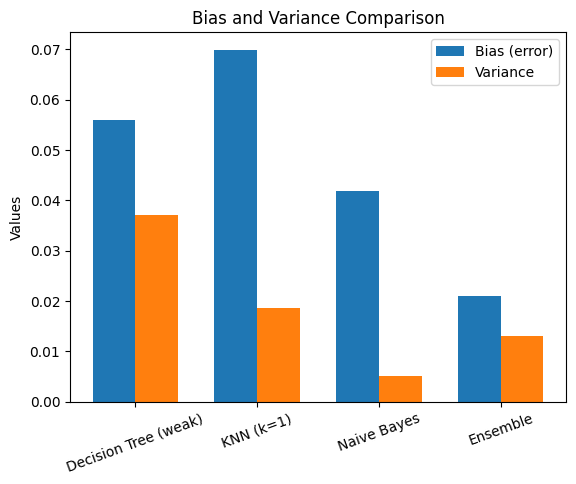

In [5]:

import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score
from sklearn.utils import resample

# Load data
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, random_state=42)

# Models
dt = DecisionTreeClassifier(max_depth=1)
knn = KNeighborsClassifier(n_neighbors=1)
nb = GaussianNB()
ensemble = VotingClassifier(estimators=[('dt', dt), ('knn', knn), ('nb', nb)], voting='hard')

models = [dt, knn, nb, ensemble]
model_names = ['Decision Tree (weak)', 'KNN (k=1)', 'Naive Bayes', 'Ensemble']

# Number of bootstrap samples
n_bootstrap = 50

# Store predictions for each bootstrap
predictions = {name: [] for name in model_names}

for i in range(n_bootstrap):
    # Bootstrap sample of training data
    X_resample, y_resample = resample(X_train, y_train, random_state=i)
    for model, name in zip(models, model_names):
        model.fit(X_resample, y_resample)
        preds = model.predict(X_test)
        predictions[name].append(preds)

# Convert to numpy arrays: shape (n_bootstrap, n_samples)
for name in model_names:
    predictions[name] = np.array(predictions[name])

# Calculate bias and variance for each model
biases = []
variances = []

for name in model_names:
    preds = predictions[name]  # shape: (n_bootstrap, n_samples)
    avg_preds = np.mean(preds, axis=0)  # average prediction per sample
    # Since classification, treat predictions as class labels, so use mode or probability
    # Approximate bias as error between avg_preds (rounded) and true label
    avg_preds_rounded = np.round(avg_preds).astype(int)
    bias = np.mean(avg_preds_rounded != y_test)

    # Variance as average variance of predictions per sample
    var = np.mean(np.var(preds, axis=0))

    biases.append(bias)
    variances.append(var)

# Print results
for name, b, v in zip(model_names, biases, variances):
    print(f"{name} -- Bias (error rate): {b:.4f}, Variance: {v:.4f}")

# Optional: plot bar chart
import matplotlib.pyplot as plt
x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, biases, width, label='Bias (error)')
rects2 = ax.bar(x + width/2, variances, width, label='Variance')

ax.set_ylabel('Values')
ax.set_title('Bias and Variance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=20)
ax.legend()
plt.show()


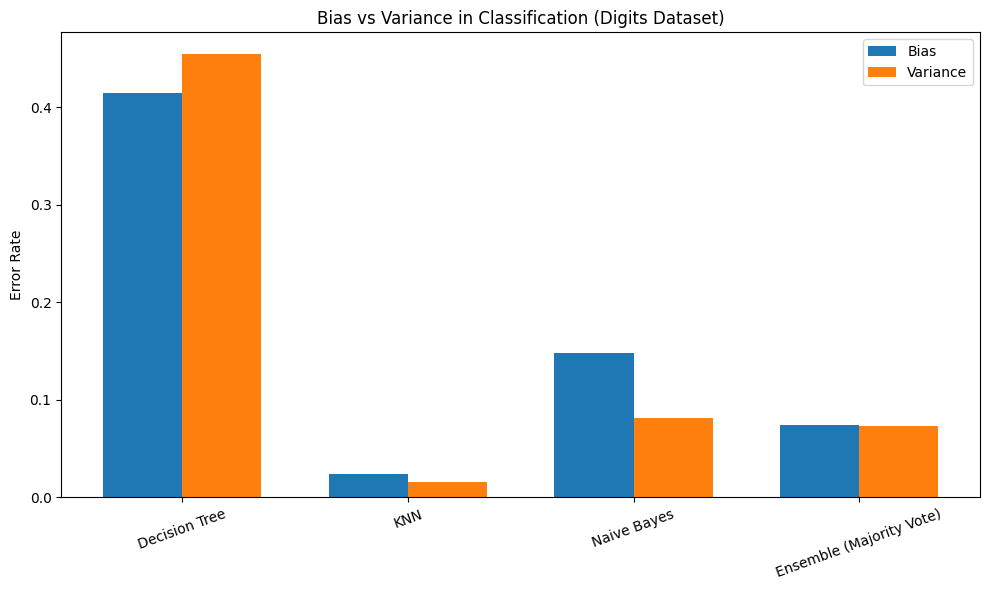

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from scipy.stats import mode

# Load data
X, y = load_digits(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Classifiers
dt = DecisionTreeClassifier(max_depth=3)      # Weak DT
knn = KNeighborsClassifier(n_neighbors=10)
nb = GaussianNB()

models = {'Decision Tree': dt, 'KNN': knn, 'Naive Bayes': nb}

n_bootstrap = 100
n_test = len(y_test)
all_preds = {name: [] for name in models}

# Bootstrap training and predictions
np.random.seed(42)
for _ in range(n_bootstrap):
    indices = np.random.choice(len(X_train), len(X_train), replace=True)
    X_boot, y_boot = X_train[indices], y_train[indices]

    for name, model in models.items():
        model.fit(X_boot, y_boot)
        preds = model.predict(X_test)
        all_preds[name].append(preds)

# Convert predictions to numpy arrays: (n_bootstrap, n_test)
for name in all_preds:
    all_preds[name] = np.array(all_preds[name])

# Function to compute classification bias and variance (0/1 loss approximation)
def classification_bias_variance(preds, y_true):
    mode_preds, _ = mode(preds, axis=0)
    mode_preds = mode_preds.flatten()
    bias = np.mean(mode_preds != y_true)
    variance = np.mean(np.mean(preds != mode_preds[None, :], axis=0))
    return bias, variance

# Compute bias and variance for each model
biases = []
variances = []
labels = []

for name, preds in all_preds.items():
    bias, var = classification_bias_variance(preds, y_test)
    biases.append(bias)
    variances.append(var)
    labels.append(name)

# Ensemble: majority vote from all 3 classifiers
ensemble_preds = np.array([
    mode([dt_preds, knn_preds, nb_preds], axis=0)[0].flatten()
    for dt_preds, knn_preds, nb_preds in zip(all_preds['Decision Tree'], all_preds['KNN'], all_preds['Naive Bayes'])
])
ensemble_bias, ensemble_var = classification_bias_variance(ensemble_preds, y_test)

# Append ensemble results
biases.append(ensemble_bias)
variances.append(ensemble_var)
labels.append('Ensemble (Majority Vote)')

# Plot bias and variance
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, biases, width, label='Bias')
plt.bar(x + width/2, variances, width, label='Variance')
plt.xticks(x, labels, rotation=20)
plt.ylabel('Error Rate')
plt.title('Bias vs Variance in Classification (Digits Dataset)')
plt.legend()
plt.tight_layout()
plt.show()
